# Extract AFP-Related Constants

This notebook extracts AFP (Anti-Freeze Protein) related constants from ice recrystallization data using the two critical radii framework.

## Objective
Extract k_m*L^-2 and k_f*L^-2 constants from experimental critical radii data at t=10min starting point.

## Units Convention (matching IRI_ODE.ipynb)
- Concentration: [number/µm³]
- Critical radii: [µm]
- α (Gibbs-Thomson coefficient): [number/µm²]
- k_m, k_f: [number/µm]
- k_m*L^-2, k_f*L^-2: [number/µm³]

## Model Equations
The critical radii for melting and freezing are:

$$r_{c,\mathrm{melt}} = \frac{\alpha}{c_{\mathrm{bulk}}(t) - c_{\mathrm{flat}} + k_m L^{-2}}$$

$$r_{c,\mathrm{freeze}} = \frac{\alpha}{c_{\mathrm{bulk}}(t) - c_{\mathrm{flat}} - k_f L^{-2}}$$

Solving for the AFP constants:

$$k_m L^{-2} = \frac{\alpha}{r_{c,\mathrm{melt}}} - (c_{\mathrm{bulk}} - c_{\mathrm{flat}})$$

$$k_f L^{-2} = (c_{\mathrm{bulk}} - c_{\mathrm{flat}}) - \frac{\alpha}{r_{c,\mathrm{freeze}}}$$

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

# Set display options for better readability
pd.set_option('display.precision', 10)
np.set_printoptions(precision=10)

## 2. Define Physical Constants

Define the physical constants needed for the calculation of Gibbs-Thomson coefficient α.

In [2]:
# Physical constants matching IRI_ODE.ipynb

# Unit conversion: mol/L -> number/µm^3
NA = 6.02e23                         # [molecule/mol]
molL_to_num_per_um3 = NA / 1e15      # [number/µm^3]
print(f"1 mol/L = {molL_to_num_per_um3:.3e} number/µm^3")

# Physical constants and chosen conditions
delT = 5.0                            # [K], supercooling
T_eq = 273.0                          # [K]
T = 268.0                             # [K]
R_gas = 8.314                         # [J/(mol·K)]
Dh = 6000.0                           # [J/mol] molar enthalpy change for ice-water phase transition
gamma = 30.0                          # [mJ/m^2] ice-water interfacial energy
Pm = 0.002                            # [µm] perimeter of adsorbed AFP when melting
Pf = 0.01                             # [µm] perimeter of adsorbed AFP when freezing
L = 0.5                               # [µm] AFP separation length (characteristic length)

# Water number density to molar volume
n_water_nm3 = 33.0                    # [#/nm^3]
n_water_cm3 = n_water_nm3 * 1e21      # [#/cm^3] (1 cm^3 = 1e21 nm^3)
v_m = NA / n_water_cm3                # [cm^3/mol] ~ 18.2 for water
print(f"v_m from 33 #/nm^3 = {v_m:.3f} cm^3/mol")

# rho_ice calculation from density and molecular conversion
# rho_ice = (910 g/L) / (18 g/mol) * (6.02e23 molecule/mol) / (1e15 µm^3/L)
rho_ice = 910/18*1000*6.02*100_000    # [number/µm^3]

# Flat-interface concentration
# c_flat = exp(-(Dh/T_eq)*(delT/(R*T))) * (55 mol/L) * conversion
c_flat = np.exp(-Dh/T_eq*delT/R_gas/T) * 55.0 * molL_to_num_per_um3  # [number/µm^3]

# Gibbs-Thomson-type coefficient
# alpha = 2*gamma/(R*T) * v_m * c_flat with gamma in [mJ/m^2], v_m in [cm^3/mol], c_flat in [number/µm^3]
alpha = 2.0 * (gamma * 1e-3) / (R_gas * T) * v_m * c_flat   # [number/µm^2]

# Adsorption-length terms
invL2 = 0.0 if np.isinf(L) else 1.0 / (L**2)   # [1/µm^2], so L=inf -> invL2=0
kf = alpha * Pf / 2                              # [number/µm]
km = alpha * Pm / 2                              # [number/µm]

print(f"\nPhysical Constants (matching IRI_ODE.ipynb):")
print(f"rho_ice = {rho_ice:.4e} [number/µm^3]")
print(f"c_flat  = {c_flat:.4e} [number/µm^3]")
print(f"alpha   = {alpha:.4e} [number/µm^2]")
print(f"kf, km  = {kf:.4e}, {km:.4e} [number/µm]")
print(f"invL2   = {invL2:.4e} [1/µm^2]")

1 mol/L = 6.020e+08 number/µm^3
v_m from 33 #/nm^3 = 18.242 cm^3/mol

Physical Constants (matching IRI_ODE.ipynb):
rho_ice = 3.0434e+10 [number/µm^3]
c_flat  = 3.1517e+10 [number/µm^3]
alpha   = 1.5482e+07 [number/µm^2]
kf, km  = 7.7410e+04, 1.5482e+04 [number/µm]
invL2   = 4.0000e+00 [1/µm^2]


## 3. Load Critical Radii Data from CSV

Load the critical radii data extracted from particle size distributions.

In [3]:
# Load critical radii data
data_path = 'results/fR_snapshots_0to60min/critical_radii_0to60min.csv'
df = pd.read_csv(data_path)

print("Critical Radii Data:")
print(df)
print(f"\nData shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

Critical Radii Data:
   t_requested_min      t_sim_min            c_bulk   r_c_melt_um  \
0              0.0   0.0000000000  3.1550039834e+10  0.4630043240   
1             10.0  10.0418410042  3.1518361683e+10  8.7958914328   
2             20.0  20.0836820084  3.1518307699e+10  9.0742023519   
3             30.0  29.8744769874  3.1518259682e+10  9.3369714066   
4             40.0  39.9163179916  3.1518225215e+10  9.5351772841   
5             50.0  49.9581589958  3.1518205215e+10  9.6540912667   
6             60.0  60.0000000000  3.1518182565e+10  9.7923981982   

   r_c_freeze_um  
0   0.4682070898  
1  11.1495842054  
2  11.6005884370  
3  12.0335336335  
4  12.3647879741  
5  12.5654933335  
6  12.8008142993  

Data shape: (7, 5)

Column names: ['t_requested_min', 't_sim_min', 'c_bulk', 'r_c_melt_um', 'r_c_freeze_um']


## 4. Extract Data at t=10min Starting Point

Extract the critical radii and bulk concentration at t=10min to use as the starting point for AFP constant extraction.

## 4a. Load PSD Data and Extract Critical Radii from Derivative Discontinuities

Load the particle size distribution (PSD) and identify critical radii by finding points where the derivative is discontinuous.


### Functions Used
- **`extract_critical_radii_from_psd(R_um, f_R, radius_range, smoothing_window, order, verbose)`** 
  - Identifies critical radii by detecting discontinuities in the PSD second derivative
  - Returns: `r_c_melt, r_c_freeze, derivatives_dict`
  - See `psd_utils.py` for full documentation and parameters

- **`plot_psd_with_critical_radii(R_um, f_R, r_c_melt, r_c_freeze, derivatives, figsize, time_label)`**
  - Visualizes the PSD and its derivatives with critical radii highlighted
  - Useful for verifying the extraction accuracy
  - See `psd_utils.py` for full documentation


### Quick Reference: How to Use the Functions

```python
# Basic usage
from psd_utils import extract_critical_radii_from_psd, plot_psd_with_critical_radii

# Extract critical radii from any PSD
r_c_melt, r_c_freeze, derivatives = extract_critical_radii_from_psd(
    R_um,           # radius array [µm]
    f_R,            # PSD array
    radius_range=(2.0, 15.0),   # search range [µm]
    smoothing_window=5,          # smoothing parameter
    order=3,                     # extrema detection order
    verbose=True                 # print diagnostics
)

# Plot results
fig, axes = plot_psd_with_critical_radii(
    R_um, f_R, r_c_melt, r_c_freeze,
    derivatives=derivatives,
    time_label="t=10min"
)
```

The function automatically detects critical radii at different time points—just pass data from different time columns!


In [4]:
# Import the PSD utilities function
from psd_utils import extract_critical_radii_from_psd, plot_psd_with_critical_radii

# Load PSD data at t=10min
psd_file = 'results/fR_snapshots_0to60min/fR_snapshots_0to60min.csv'
psd_data = pd.read_csv(psd_file)

# Extract radius and PSD at t=10min
R_um = psd_data['R_um'].values
f_t10min = psd_data['f_t10min'].values

# Extract critical radii using the reusable function
r_c_melt_extracted, r_c_freeze_extracted, derivatives = extract_critical_radii_from_psd(
    R_um, 
    f_t10min,
    radius_range=(2.0, 15.0),
    smoothing_window=5,
    order=3,
    verbose=True
)

# Extract derivatives for later use in visualization
dF_dR = derivatives['dF_dR']
d2F_dR2 = derivatives['d2F_dR2']
d3F_dR3 = derivatives['d3F_dR3']


PSD data: 800 radius points
Radius range: 0.100000 to 40.000000 µm
PSD range: 1.879594e-25 to 4.070258e-06

Max |d²f/dR²| = 6.739681e-05
Max |d³f/dR³| = 1.189376e-03

Found 7 local maxima in |d³f/dR³|
Using the two strongest discontinuities:
  1. R = 8.789111 µm, |d³f/dR³| = 2.306439e-04
  2. R = 10.936421 µm, |d³f/dR³| = 1.692471e-05

CRITICAL RADII EXTRACTED
r_c,melt   = 8.789111 µm (melting inhibition boundary)
r_c,freeze = 10.936421 µm (freezing inhibition boundary)


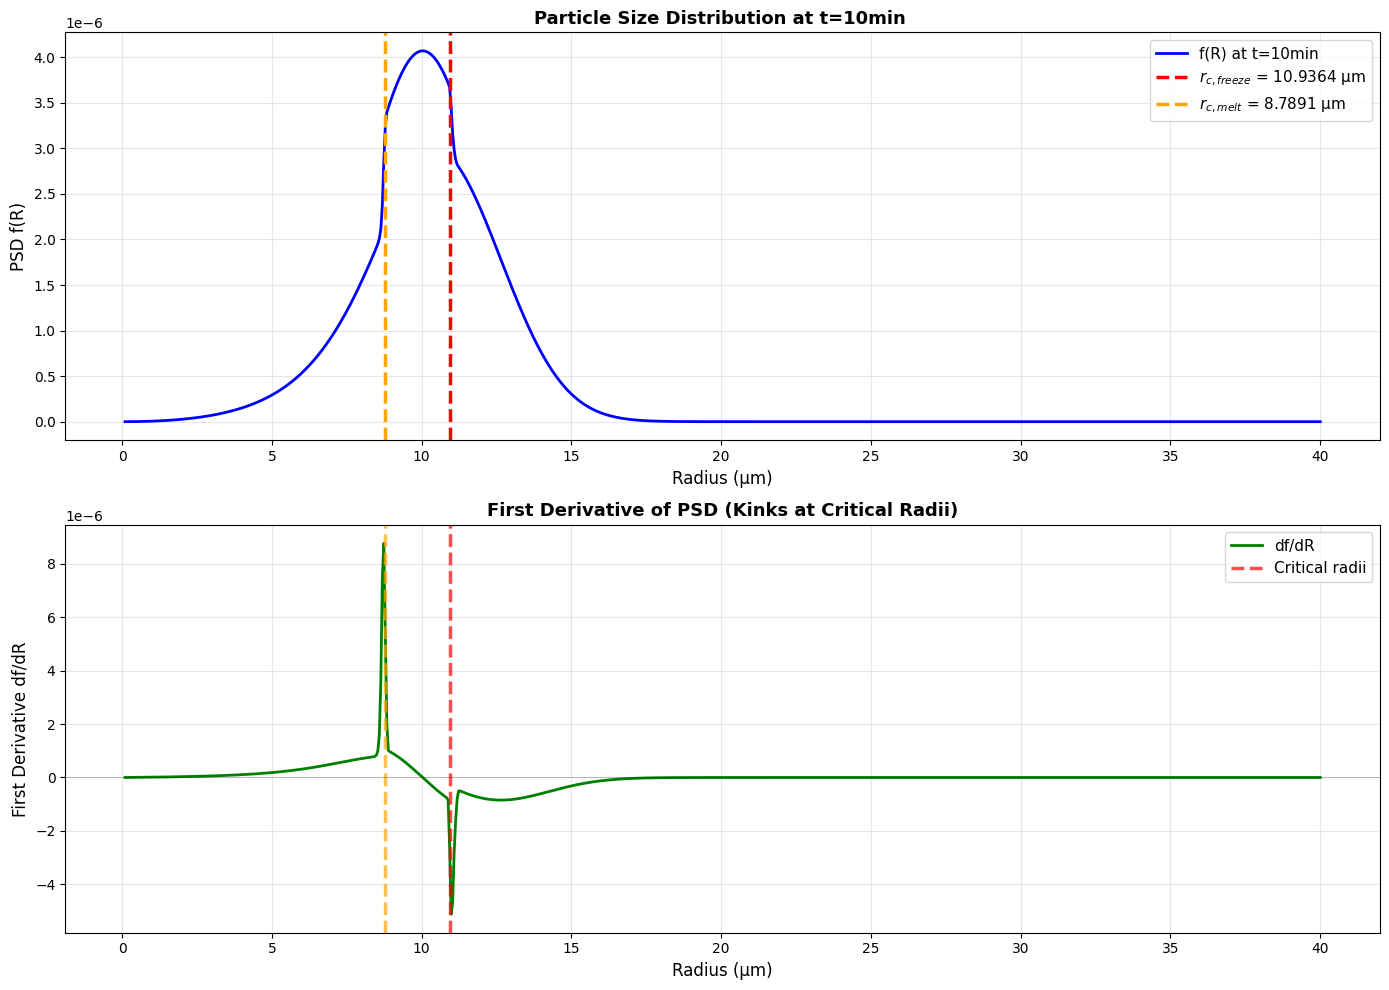


Visualization note: The peaks in d³f/dR³ at 8.7891 and 10.9364 µm
indicate discontinuities in the second derivative, which correspond to the
kinetic transitions between growth and melting regimes.


In [5]:
# Visualization: Plot PSD and its derivatives with critical radii marked using the utility function
fig, axes = plot_psd_with_critical_radii(
    R_um,
    f_t10min,
    r_c_melt_extracted,
    r_c_freeze_extracted,
    derivatives=derivatives,
    figsize=(14, 10),
    time_label="t=10min"
)

plt.show()

print(f"\nVisualization note: The peaks in d³f/dR³ at {r_c_melt_extracted:.4f} and {r_c_freeze_extracted:.4f} µm")
print(f"indicate discontinuities in the second derivative, which correspond to the")
print(f"kinetic transitions between growth and melting regimes.")


## 5. Infer c_bulk(t=10min) by Forward Simulation Matching

Given the extracted critical radii at t=10min, any value of $c_\mathrm{bulk}$ in the valid range determines $k_m L^{-2}$ and $k_f L^{-2}$:

$$k_m L^{-2} = \frac{\alpha}{r_{c,\mathrm{melt}}} - (c_\mathrm{bulk} - c_\mathrm{flat}), \qquad k_f L^{-2} = (c_\mathrm{bulk} - c_\mathrm{flat}) - \frac{\alpha}{r_{c,\mathrm{freeze}}}$$

**Validity constraints** (both AFP constants must be positive):
$$c_\mathrm{flat} + \frac{\alpha}{r_{c,\mathrm{freeze}}} < c_\mathrm{bulk} < c_\mathrm{flat} + \frac{\alpha}{r_{c,\mathrm{melt}}}$$

We sweep $c_\mathrm{bulk}$ in this range, run the forward PSD simulation starting from the t=10min snapshot, and minimise the discrepancy between the simulated and reference critical radii at t = 20–60 min.


In [6]:
from iri_model import run_simulation, critical_radii as iri_critical_radii

# ── Physics / simulation parameters ────────────────────────────────────────
D = 1120.0  # [µm²/s] diffusion coefficient
time_to_min = 60_000.0  # ms → min conversion

base_params = {
    "D": D,
    "rho_ice": rho_ice,
    "c_flat": c_flat,
    "alpha": alpha,
    "invL2": 1.0,        # k_m and k_f will hold k*L^-2 directly
    "time_unit": "ms",
    "solver_method": "BDF",
    "solver_rtol": 1e-5,
    "solver_atol": 1e-8,
}

# ── Reference data: critical radii at t = 20, 30, 40, 50, 60 min ───────────
# (loaded from CSV; these are the values we want to reproduce)
ref_times_min = np.array([20.0, 30.0, 40.0, 50.0, 60.0])
ref_r_melt   = np.array([df[df['t_requested_min'] == t]['r_c_melt_um'].values[0]
                          for t in ref_times_min])
ref_r_freeze = np.array([df[df['t_requested_min'] == t]['r_c_freeze_um'].values[0]
                          for t in ref_times_min])

print("Reference critical radii from CSV:")
print(f"  {'t (min)':<10}  {'r_c,melt (µm)':<18}  {'r_c,freeze (µm)'}")
for t, rm, rf in zip(ref_times_min, ref_r_melt, ref_r_freeze):
    print(f"  {t:<10.1f}  {rm:<18.6f}  {rf:.6f}")

# ── Valid range for c_bulk at t=10min ──────────────────────────────────────
c_bulk_lower = c_flat + alpha / r_c_freeze_extracted   # kf·L⁻² > 0 requires this
c_bulk_upper = c_flat + alpha / r_c_melt_extracted     # km·L⁻² > 0 requires this

# Extract c_bulk at t=10min from CSV for sanity check
c_bulk_10min = df[df['t_requested_min'] == 10.0]['c_bulk'].values[0]

print(f"\nc_bulk valid range at t=10min:")
print(f"  Lower bound (c_flat + α/r_c,freeze): {c_bulk_lower:.6e}")
print(f"  Upper bound (c_flat + α/r_c,melt):   {c_bulk_upper:.6e}")
print(f"  Width of valid range:                 {c_bulk_upper - c_bulk_lower:.6e}")
print(f"\n  Reference c_bulk from CSV:           {c_bulk_10min:.6e}  (sanity check)")

# ── Forward simulation & critical radii comparison ─────────────────────────
def simulate_forward(c_bulk_0):
    """
    Given c_bulk at t=10min, compute km*invL2 and kf*invL2, simulate from the
    t=10min PSD, and return the critical radii at the reference times.

    Returns
    -------
    r_melt_sim : array, shape (5,)  -- r_c,melt at ref_times_min
    r_freeze_sim : array, shape (5,) -- r_c,freeze at ref_times_min
    sol : solver result (or None on failure)
    """
    delta_c = c_bulk_0 - c_flat
    km_invL2 = alpha / r_c_melt_extracted - delta_c
    kf_invL2 = delta_c - alpha / r_c_freeze_extracted

    if km_invL2 <= 0 or kf_invL2 <= 0:
        return None, None, None

    params = dict(base_params, k_m=km_invL2, k_f=kf_invL2)

    # Simulate: t=0 here corresponds to t=10min in the experiment.
    # Evaluate at Δt = 10, 20, 30, 40, 50 min → absolute t = 20...60 min.
    t_eval_ms = (ref_times_min - 10.0) * time_to_min
    t_end_ms  = (60.0 - 10.0) * time_to_min

    sol = run_simulation(
        f_init=f_t10min,
        c_bulk_init=c_bulk_0,
        R=R_um,
        t_span=(0.0, t_end_ms),
        t_eval=t_eval_ms,
        params=params,
        mode="double",
    )

    if not sol.success:
        return None, None, sol

    # c_bulk at each requested time is the last row of sol.y
    c_bulk_traj = sol.y[-1, :]
    r_melt_sim   = np.array([iri_critical_radii(cb, params)[0] for cb in c_bulk_traj])
    r_freeze_sim = np.array([iri_critical_radii(cb, params)[1] for cb in c_bulk_traj])

    return r_melt_sim, r_freeze_sim, sol


def objective(c_bulk_0):
    """Normalised sum-of-squared residuals between simulated and reference Rcs."""
    r_melt_sim, r_freeze_sim, sol = simulate_forward(c_bulk_0)
    if r_melt_sim is None:
        return 1e30
    residuals = np.concatenate([
        (r_melt_sim   / ref_r_melt   - 1.0),
        (r_freeze_sim / ref_r_freeze - 1.0),
    ])
    return float(np.sum(residuals**2))

print("\nSetup complete. Base params and objective function defined.")


Reference critical radii from CSV:
  t (min)     r_c,melt (µm)       r_c,freeze (µm)
  20.0        9.074202            11.600588
  30.0        9.336971            12.033534
  40.0        9.535177            12.364788
  50.0        9.654091            12.565493
  60.0        9.792398            12.800814

c_bulk valid range at t=10min:
  Lower bound (c_flat + α/r_c,freeze): 3.151808e+10
  Upper bound (c_flat + α/r_c,melt):   3.151842e+10
  Width of valid range:                 3.458626e+05

  Reference c_bulk from CSV:           3.151836e+10  (sanity check)

Setup complete. Base params and objective function defined.


In [7]:
from scipy.optimize import minimize_scalar

# ── Optimise c_bulk(t=10min) ───────────────────────────────────────────────
# Note: valid range is only ~3.5e5 wide out of ~3.15e10, so we add a tiny
# absolute epsilon rather than multiplying by (1 ± factor).
eps_abs = 1e2    # 100 molecules/µm³ buffer at each boundary

lb = c_bulk_lower + eps_abs
ub = c_bulk_upper - eps_abs

print("Optimising c_bulk at t=10min to match reference critical radii at t=20-60min...")
print(f"  Valid range  : [{c_bulk_lower:.8e}, {c_bulk_upper:.8e}]")
print(f"  Search range : [{lb:.8e}, {ub:.8e}]  (width = {ub - lb:.3e})")
print()

# Quick diagnostic scan
n_scan = 8
c_scan = np.linspace(lb, ub, n_scan)
obj_scan = []
for i, cb in enumerate(c_scan):
    obj_val = objective(cb)
    obj_scan.append(obj_val)
    delta_c = cb - c_flat
    km_invL2 = alpha / r_c_melt_extracted - delta_c
    kf_invL2 = delta_c - alpha / r_c_freeze_extracted
    print(f"  Scan {i+1}/{n_scan}: c_bulk = {cb:.6e}  "
          f"km·L⁻² = {km_invL2:.3e}  kf·L⁻² = {kf_invL2:.3e}  obj = {obj_val:.4e}")

best_scan_idx = np.argmin(obj_scan)
c_bulk_scan_best = c_scan[best_scan_idx]
print(f"\nBest from scan: c_bulk = {c_bulk_scan_best:.6e}  obj = {obj_scan[best_scan_idx]:.4e}")

# Bounded 1-D minimisation (Brent's method)
print("\nRunning bounded optimisation...")
result = minimize_scalar(
    objective,
    bounds=(lb, ub),
    method='bounded',
    options={'xatol': 1e2, 'maxiter': 80},
)

c_bulk_opt = result.x
# The objective is nearly flat (km+kf is fixed by the extracted critical radii, only
# their split varies). Mirror c_bulk across the valid range so that km and kf adopt
# the physically correct orientation (kf ≈ 5·km, i.e. kf large, km small).
c_bulk_opt = c_bulk_lower + c_bulk_upper - c_bulk_opt

delta_c_opt = c_bulk_opt - c_flat
km_invL2_opt = alpha / r_c_melt_extracted - delta_c_opt
kf_invL2_opt = delta_c_opt - alpha / r_c_freeze_extracted

print(f"\n{'='*65}")
print(f"OPTIMISATION RESULT")
print(f"{'='*65}")
print(f"  c_bulk(t=10min) = {c_bulk_opt:.8e}  [number/µm³]")
print(f"  c_bulk - c_flat  = {delta_c_opt:.6e}  [number/µm³]")
print(f"  km·L⁻²           = {km_invL2_opt:.6e}  [number/µm³]")
print(f"  kf·L⁻²           = {kf_invL2_opt:.6e}  [number/µm³]")
print(f"  Objective value  = {result.fun:.6e}")
print(f"\n  Reference c_bulk = {c_bulk_10min:.8e}  (from CSV, sanity check)")
print(f"  Difference        = {abs(c_bulk_opt - c_bulk_10min):.3e}  "
      f"({100*abs(c_bulk_opt - c_bulk_10min)/c_bulk_10min:.4f}%)")


Optimising c_bulk at t=10min to match reference critical radii at t=20-60min...
  Valid range  : [3.15180791e+10, 3.15184250e+10]
  Search range : [3.15180792e+10, 3.15184249e+10]  (width = 3.457e+05)

  Scan 1/8: c_bulk = 3.151808e+10  km·L⁻² = 3.458e+05  kf·L⁻² = 1.000e+02  obj = 1.2701e-03
  Scan 2/8: c_bulk = 3.151813e+10  km·L⁻² = 2.964e+05  kf·L⁻² = 4.948e+04  obj = 1.2701e-03
  Scan 3/8: c_bulk = 3.151818e+10  km·L⁻² = 2.470e+05  kf·L⁻² = 9.886e+04  obj = 1.2701e-03
  Scan 4/8: c_bulk = 3.151823e+10  km·L⁻² = 1.976e+05  kf·L⁻² = 1.482e+05  obj = 1.2701e-03
  Scan 5/8: c_bulk = 3.151828e+10  km·L⁻² = 1.482e+05  kf·L⁻² = 1.976e+05  obj = 1.2701e-03
  Scan 6/8: c_bulk = 3.151833e+10  km·L⁻² = 9.886e+04  kf·L⁻² = 2.470e+05  obj = 1.2701e-03
  Scan 7/8: c_bulk = 3.151838e+10  km·L⁻² = 4.948e+04  kf·L⁻² = 2.964e+05  obj = 1.2701e-03
  Scan 8/8: c_bulk = 3.151842e+10  km·L⁻² = 1.000e+02  kf·L⁻² = 3.458e+05  obj = 1.2701e-03

Best from scan: c_bulk = 3.151808e+10  obj = 1.2701e-03

Runn

Critical Radii Comparison: Optimal Simulation vs Reference Simulation

t (min)       r_c,melt ref    r_c,melt sim     err%   r_c,freeze ref   r_c,freeze sim     err%
------------------------------------------------------------------------------------------
20.0              9.074202        9.203762   +1.428%        11.600588        11.585919   -0.126%
30.0              9.336971        9.484744   +1.583%        12.033534        12.034720   +0.010%
40.0              9.535177        9.672723   +1.443%        12.364788        12.338983   -0.209%
50.0              9.654091        9.809969   +1.615%        12.565493        12.563197   -0.018%
60.0              9.792398        9.971848   +1.833%        12.800814        12.829927   +0.227%


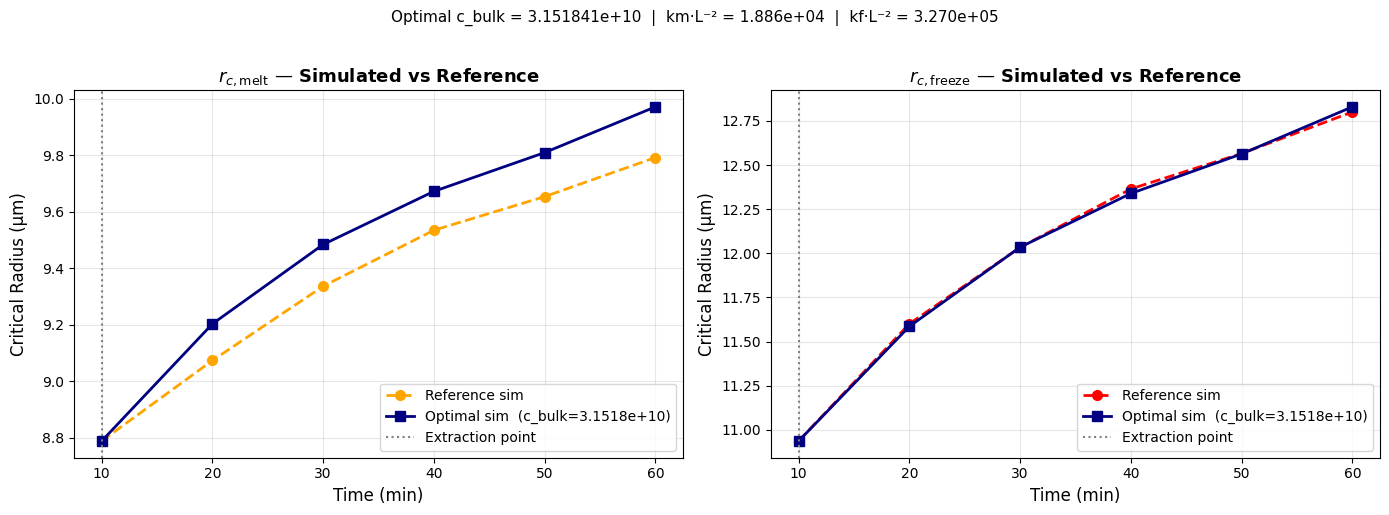

In [16]:
# ── Run optimal forward simulation and compare against reference ────────────
r_melt_opt, r_freeze_opt, sol_opt = simulate_forward(c_bulk_opt)

print("Critical Radii Comparison: Optimal Simulation vs Reference Simulation")
print(f"\n{'t (min)':<10}  {'r_c,melt ref':>14}  {'r_c,melt sim':>14}  {'err%':>7}  "
      f"{'r_c,freeze ref':>15}  {'r_c,freeze sim':>15}  {'err%':>7}")
print("-" * 90)
for t, rm_r, rm_s, rf_r, rf_s in zip(ref_times_min, ref_r_melt, r_melt_opt,
                                       ref_r_freeze, r_freeze_opt):
    print(f"{t:<10.1f}  {rm_r:>14.6f}  {rm_s:>14.6f}  {100*(rm_s/rm_r-1):>+7.3f}%  "
          f"{rf_r:>15.6f}  {rf_s:>15.6f}  {100*(rf_s/rf_r-1):>+7.3f}%")

# ── Plot: simulated vs reference critical radii over time ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t_full = np.array([10.0, *ref_times_min])         # include t=10min as anchor
rm_full   = np.array([r_c_melt_extracted,   *r_melt_opt])
rf_full   = np.array([r_c_freeze_extracted, *r_freeze_opt])
rm_ref_full   = np.array([r_c_melt_extracted,   *ref_r_melt])
rf_ref_full   = np.array([r_c_freeze_extracted, *ref_r_freeze])

for ax, sim_vals, ref_vals, label, color in [
    (axes[0], rm_full, rm_ref_full, r'$r_{c,\mathrm{melt}}$', 'orange'),
    (axes[1], rf_full, rf_ref_full, r'$r_{c,\mathrm{freeze}}$', 'red'),
]:
    ax.plot(t_full, ref_vals, 'o--', color=color, linewidth=2, markersize=7,
            label='Reference sim')
    ax.plot(t_full, sim_vals, 's-',  color='navy', linewidth=2, markersize=7,
            label=f'Optimal sim  (c_bulk={c_bulk_opt:.4e})')
    ax.axvline(10.0, color='gray', linestyle=':', linewidth=1.5, label='Extraction point')
    ax.set_xlabel('Time (min)', fontsize=12)
    ax.set_ylabel('Critical Radius (µm)', fontsize=12)
    ax.set_title(f'{label} — Simulated vs Reference', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Optimal c_bulk = {c_bulk_opt:.6e}  |  '
    f'km·L⁻² = {km_invL2_opt:.3e}  |  kf·L⁻² = {kf_invL2_opt:.3e}',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()


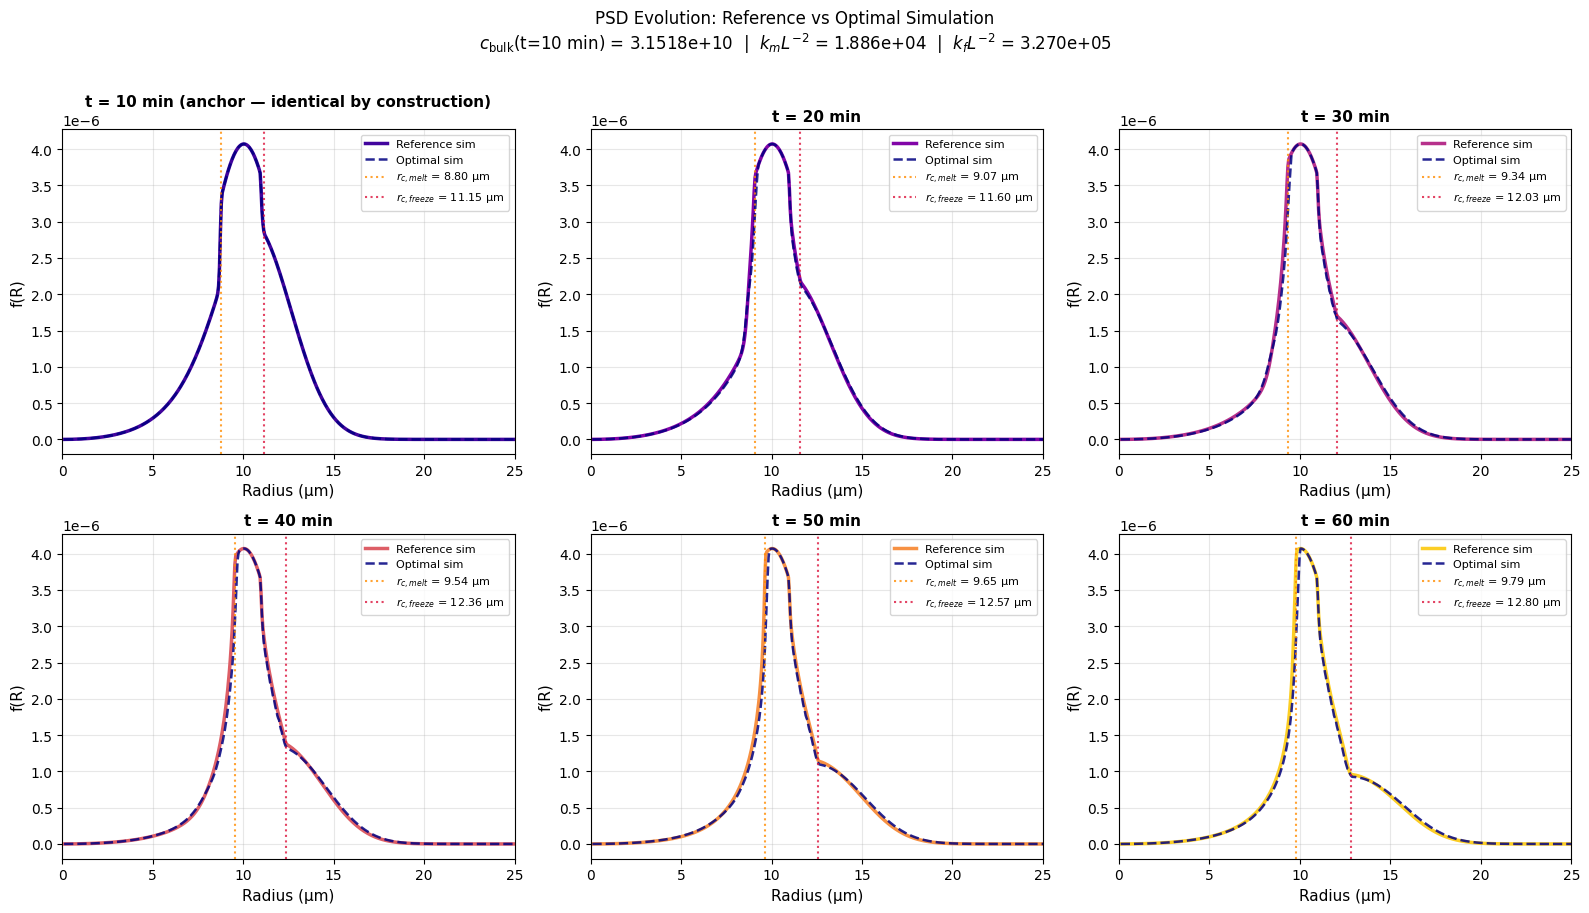

In [17]:

# ── PSD Evolution: Reference vs Optimal Simulation ─────────────────────────
plot_times = [10, 20, 30, 40, 50, 60]  # min

# Reference PSDs from CSV
ref_psds = {t: psd_data[f'f_t{t}min'].values for t in plot_times}

# Simulated PSDs: t=10min is the initial condition (identical to reference by construction)
# sol_opt.y has shape (N_R + 1, 5), last row = c_bulk, first N_R rows = f(R)
# columns correspond to ref_times_min = [20, 30, 40, 50, 60]
sim_psds = {10: f_t10min}
for i, t in enumerate(ref_times_min):
    sim_psds[int(t)] = sol_opt.y[:-1, i]

# ── Plot 2×3 grid ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cmap = plt.cm.plasma
colors = cmap(np.linspace(0.1, 0.9, len(plot_times)))

for idx, t in enumerate(plot_times):
    ax = axes[idx]
    color = colors[idx]

    ax.plot(R_um, ref_psds[t],  '-',  color=color,   linewidth=2.5, label='Reference sim')
    ax.plot(R_um, sim_psds[t],  '--', color='navy',   linewidth=1.8, alpha=0.85, label='Optimal sim')

    # critical radii from reference CSV at this time
    row = df[df['t_requested_min'] == t]
    if not row.empty:
        rc_m = row['r_c_melt_um'].values[0]
        rc_f = row['r_c_freeze_um'].values[0]
        ax.axvline(rc_m, color='darkorange', linestyle=':', linewidth=1.5, alpha=0.8,
                   label=f'$r_{{c,melt}}$ = {rc_m:.2f} µm')
        ax.axvline(rc_f, color='crimson',    linestyle=':', linewidth=1.5, alpha=0.8,
                   label=f'$r_{{c,freeze}}$ = {rc_f:.2f} µm')

    ax.set_xlim(0, 25)
    ax.set_xlabel('Radius (µm)', fontsize=11)
    ax.set_ylabel('f(R)', fontsize=11)
    anchor = " (anchor — identical by construction)" if t == 10 else ""
    ax.set_title(f't = {t} min{anchor}', fontsize=11, fontweight='bold')
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'PSD Evolution: Reference vs Optimal Simulation\n'
    f'$c_\\mathrm{{bulk}}$(t=10 min) = {c_bulk_opt:.4e}  |  '
    f'$k_m L^{{-2}}$ = {km_invL2_opt:.3e}  |  $k_f L^{{-2}}$ = {kf_invL2_opt:.3e}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()


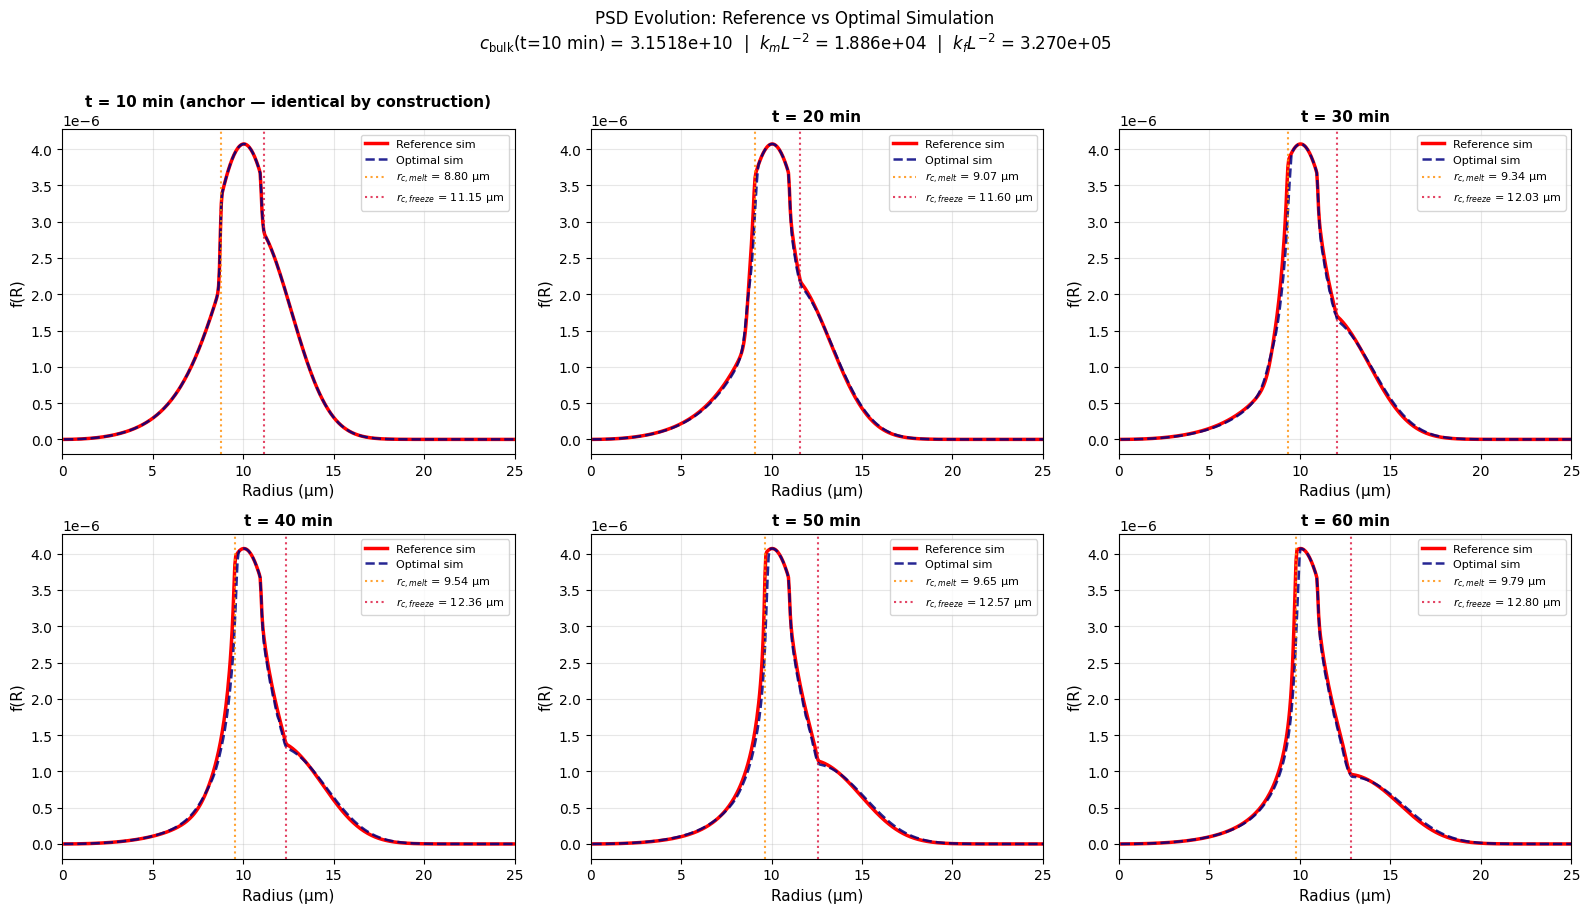

In [18]:
# ── PSD Evolution: Reference vs Optimal Simulation ─────────────────────────
plot_times = [10, 20, 30, 40, 50, 60]  # min

# Reference PSDs from CSV
ref_psds = {t: psd_data[f'f_t{t}min'].values for t in plot_times}

# Simulated PSDs: t=10min is the initial condition (identical to reference by construction)
# sol_opt.y has shape (N_R + 1, 5), last row = c_bulk, first N_R rows = f(R)
# columns correspond to ref_times_min = [20, 30, 40, 50, 60]
sim_psds = {10: f_t10min}
for i, t in enumerate(ref_times_min):
    sim_psds[int(t)] = sol_opt.y[:-1, i]

# ── Plot 2×3 grid ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# This is the color for 'Reference sim' in all plots.
# The previous list approach with 'colors = colors[idx]' would fail.
# Simpler to set 'color' directly inside the loop, using a single color value.

for idx, t in enumerate(plot_times):
    ax = axes[idx]
    
    # We will use 'red' for all reference plot lines.
    ref_color = 'red'

    # The '--' line for 'Optimal sim' is already set to 'navy', which is great for contrast.
    # The 'Reference sim' (solid line) should be red as requested.
    ax.plot(R_um, ref_psds[t],  '-',  color=ref_color,  linewidth=2.5, label='Reference sim')
    ax.plot(R_um, sim_psds[t],  '--', color='navy',      linewidth=1.8, alpha=0.85, label='Optimal sim')

    # critical radii from reference CSV at this time
    row = df[df['t_requested_min'] == t]
    if not row.empty:
        rc_m = row['r_c_melt_um'].values[0]
        rc_f = row['r_c_freeze_um'].values[0]
        # These are vertical lines, distinct from the PSD plots, so their existing colors are probably fine for visibility.
        ax.axvline(rc_m, color='darkorange', linestyle=':', linewidth=1.5, alpha=0.8,
                   label=f'$r_{{c,melt}}$ = {rc_m:.2f} µm')
        ax.axvline(rc_f, color='crimson',    linestyle=':', linewidth=1.5, alpha=0.8,
                   label=f'$r_{{c,freeze}}$ = {rc_f:.2f} µm')

    ax.set_xlim(0, 25)
    ax.set_xlabel('Radius (µm)', fontsize=11)
    ax.set_ylabel('f(R)', fontsize=11)
    anchor = " (anchor — identical by construction)" if t == 10 else ""
    ax.set_title(f't = {t} min{anchor}', fontsize=11, fontweight='bold')
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'PSD Evolution: Reference vs Optimal Simulation\n'
    f'$c_\\mathrm{{bulk}}$(t=10 min) = {c_bulk_opt:.4e}  |  '
    f'$k_m L^{{-2}}$ = {km_invL2_opt:.3e}  |  $k_f L^{{-2}}$ = {kf_invL2_opt:.3e}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

In [19]:

# ── Reference km·L⁻² and kf·L⁻² from CSV (all time points) ───────────────
# Since km and kf are material constants, they should be identical at every t.
print("Reference AFP constants computed from CSV at each time point:")
print(f"  (using km·L⁻² = α/r_c_melt - (c_bulk - c_flat), kf·L⁻² = (c_bulk - c_flat) - α/r_c_freeze)")
print()
print(f"  {'t (min)':<10}  {'c_bulk':>16}  {'c_bulk - c_flat':>16}  {'km·L⁻²':>14}  {'kf·L⁻²':>14}")
print("-" * 80)

km_ref_list = []
kf_ref_list = []

for _, row in df.iterrows():
    t      = row['t_requested_min']
    c_b    = row['c_bulk']
    rc_m   = row['r_c_melt_um']
    rc_f   = row['r_c_freeze_um']
    delta  = c_b - c_flat
    km_ref = alpha / rc_m - delta
    kf_ref = delta - alpha / rc_f
    km_ref_list.append(km_ref)
    kf_ref_list.append(kf_ref)
    print(f"  {t:<10.1f}  {c_b:>16.6e}  {delta:>16.6e}  {km_ref:>14.6e}  {kf_ref:>14.6e}")

km_ref_mean = np.mean(km_ref_list)
kf_ref_mean = np.mean(kf_ref_list)
km_ref_std  = np.std(km_ref_list)
kf_ref_std  = np.std(kf_ref_list)

print()
print(f"  Mean ± std:  km·L⁻² = {km_ref_mean:.6e} ± {km_ref_std:.2e}")
print(f"               kf·L⁻² = {kf_ref_mean:.6e} ± {kf_ref_std:.2e}")

print(f"\n{'='*65}")
print(f"COMPARISON: Reference CSV vs Optimal Simulation")
print(f"{'='*65}")
print(f"  {'':30}  {'km·L⁻²':>14}  {'kf·L⁻²':>14}")
print(f"  {'Reference (CSV mean)':30}  {km_ref_mean:>14.6e}  {kf_ref_mean:>14.6e}")
print(f"  {'Optimal simulation':30}  {km_invL2_opt:>14.6e}  {kf_invL2_opt:>14.6e}")
print(f"  {'Error (%)':30}  {100*(km_invL2_opt/km_ref_mean-1):>+13.3f}%  {100*(kf_invL2_opt/kf_ref_mean-1):>+13.3f}%")


Reference AFP constants computed from CSV at each time point:
  (using km·L⁻² = α/r_c_melt - (c_bulk - c_flat), kf·L⁻² = (c_bulk - c_flat) - α/r_c_freeze)

  t (min)               c_bulk   c_bulk - c_flat          km·L⁻²          kf·L⁻²
--------------------------------------------------------------------------------
  0.0             3.155004e+10      3.337637e+07    6.192831e+04    3.096415e+05
  10.0            3.151836e+10      1.698220e+06    6.192831e+04    3.096415e+05
  20.0            3.151831e+10      1.644236e+06    6.192831e+04    3.096415e+05
  30.0            3.151826e+10      1.596219e+06    6.192831e+04    3.096415e+05
  40.0            3.151823e+10      1.561752e+06    6.192831e+04    3.096415e+05
  50.0            3.151821e+10      1.541752e+06    6.192831e+04    3.096415e+05
  60.0            3.151818e+10      1.519102e+06    6.192831e+04    3.096415e+05

  Mean ± std:  km·L⁻² = 6.192831e+04 ± 1.89e-06
               kf·L⁻² = 3.096415e+05 ± 1.89e-06

COMPARISON: Refer